In [1]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.precision', 20)

# Collisions with new mass less than min_frag_mass and collisions with the sun

## randseed = 3

In [2]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [5]:
famtree_bigstep_3 = pd.read_csv(
    "famtree_bigstep_3",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

In [8]:
heartbeat_column_names = [
    "t", "walltime", "N", "total_mass", 
    "ang_mom_x", "ang_mom_y", "ang_mom_z", "energy", 
    "p3_m", "p3_r", "p3_x", "p3_y", "p3_z", "p3_vx", "p3_vy", "p3_vz",
    "p0_m", "p0_r", "p0_x", "p0_y", "p0_z", "p0_vx", "p0_vy", "p0_vz"
]

# Read the files
heartbeat_bigstep_3 = pd.read_csv(
    "heartbeat_bigstep_3", 
    names=heartbeat_column_names, 
    header=None
)

In [9]:
# 1. Get initial values (from the first row)
initial_mass = heartbeat_bigstep_3["total_mass"].iloc[0]
initial_energy = heartbeat_bigstep_3["energy"].iloc[0]

L_x0 = heartbeat_bigstep_3["ang_mom_x"].iloc[0]
L_y0 = heartbeat_bigstep_3["ang_mom_y"].iloc[0]
L_z0 = heartbeat_bigstep_3["ang_mom_z"].iloc[0]
initial_L_mag = np.sqrt(L_x0**2 + L_y0**2 + L_z0**2)

# 2. Calculate current angular momentum magnitude for all rows
current_L_mag = np.sqrt(
    heartbeat_bigstep_3["ang_mom_x"]**2 + 
    heartbeat_bigstep_3["ang_mom_y"]**2 + 
    heartbeat_bigstep_3["ang_mom_z"]**2
)

# 3. Add the relative error columns
heartbeat_bigstep_3["mass_error"] = abs((heartbeat_bigstep_3["total_mass"] - initial_mass) / initial_mass)
heartbeat_bigstep_3["energy_error"] = abs((heartbeat_bigstep_3["energy"] - initial_energy) / initial_energy)
heartbeat_bigstep_3["angular_momentum_error"] = abs((current_L_mag - initial_L_mag) / initial_L_mag)

In [10]:
famtree_less_than_min_mass = famtree_bigstep_3[famtree_bigstep_3['new_mass'] < 1.4e-8]
famtree_less_than_min_mass

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp


In [11]:
famtree_with_sun = famtree_bigstep_3[(np.isclose(famtree_bigstep_3['parent1_mass'], 1)) | (np.isclose(famtree_bigstep_3['parent2_mass'], 1))]
famtree_with_sun

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp


/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_45920/2751911901.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


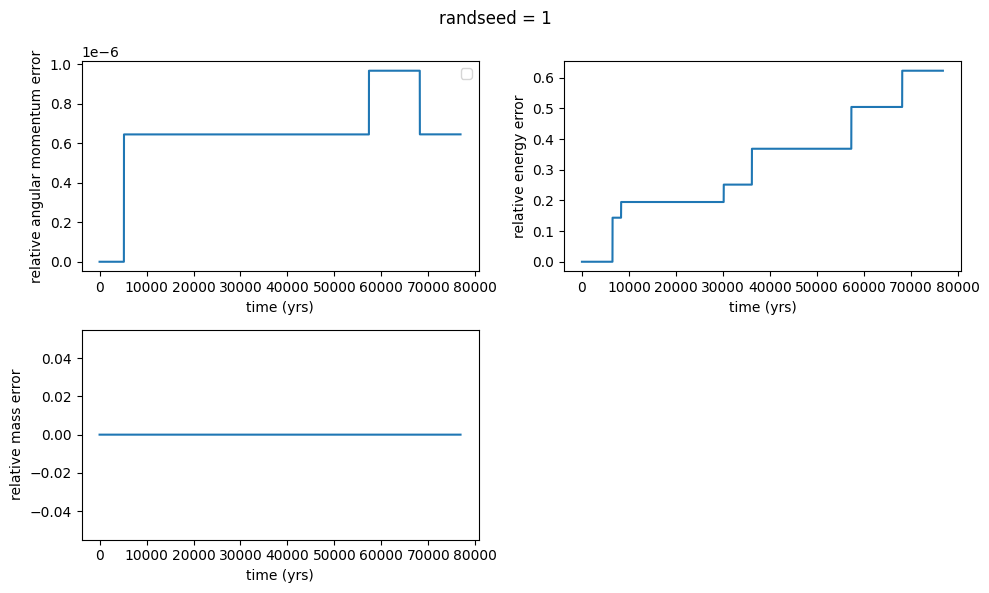

In [12]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.plot(heartbeat_bigstep_3['t'], heartbeat_bigstep_3['angular_momentum_error'])
plt.legend()
plt.xlabel("time (yrs)")
plt.ylabel("relative angular momentum error")

plt.subplot(2,2,2)
plt.plot(heartbeat_bigstep_3['t'], heartbeat_bigstep_3['energy_error'])
plt.xlabel("time (yrs)")
plt.ylabel("relative energy error")

plt.subplot(2,2,3)
plt.plot(heartbeat_bigstep_3['t'], heartbeat_bigstep_3['mass_error'])
plt.xlabel("time (yrs)")
plt.ylabel("relative mass error")

plt.suptitle("randseed = 1")
plt.tight_layout()

In [13]:
heartbeat_bigstep_3

,t,walltime,N,total_mass,ang_mom_x,ang_mom_y,ang_mom_z,energy,p3_m,p3_r,...,p0_r,p0_x,p0_y,p0_z,p0_vx,p0_vy,p0_vz,mass_error,energy_error,angular_momentum_error
0,0.00000000000000000000,0.00000000000000000000,31,1.00000899999999992573,0.000000003733960,-0.00000001006736,0.00003104342,-0.00059244150000000004,0.0000003063898,0.00002437613,...,0.00464999999999999962,-0.00000072922540000000,0.00000023810320000000,-0.00000000296224300000,-0.000008523202,-0.000026017280,0.0000001591461,0.0,0.00000000000000000000,0.00000000000000000000
1,0.00130754299999999999,0.00055199999999999997,31,1.00000899999999992573,0.000000003733960,-0.00000001006736,0.00003104342,-0.00059244150000000004,0.0000003063898,0.00002437613,...,0.00464999999999999962,-0.00000073967080000000,0.00000020357920000000,-0.00000000274149500000,-0.000007432703,-0.000026788240,0.0000001782521,0.0,0.00000000000000000000,0.00000000000000000000
2,0.01702970999999999999,0.00178999999999999992,31,1.00000899999999992573,0.000000003733960,-0.00000001006736,0.00003104342,-0.00059244150000000004,0.0000003063898,0.00002437613,...,0.00464999999999999962,-0.00000070414290000000,-0.00000025405560000000,0.00000000097967490000,0.000013624570,-0.000027754950,0.0000002401543,0.0,0.00000000000000000000,0.00000000000000000000
3,0.03292718000000000034,0.00299599999999999997,31,1.00000899999999992573,0.000000003733960,-0.00000001006736,0.00003104342,-0.00059244150000000004,0.0000003063898,0.00002437613,...,0.00464999999999999962,-0.00000036086820000000,-0.00000054248230000000,0.00000000383368500000,0.000024880260,-0.000006617115,0.0000001265182,0.0,0.00000000000000000000,0.00000000000000000000
4,0.05027969000000000188,0.00429400000000000007,31,1.00000899999999992573,0.000000003733960,-0.00000001006736,0.00003104342,-0.00059244150000000004,0.0000003063898,0.00002437613,...,0.00464999999999999962,-0.00000002397498000000,-0.00000051374150000000,0.00000000602497900000,0.000012947050,0.000005165579,0.0000001362952,0.0,0.00000000000000000000,0.00000000000000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4675122,76848.52999999999883584678,9916.87318199999936041422,64,1.00000899999999992573,0.000000003753626,-0.00000001003060,0.00003104340,-0.00022360130000000000,0.0000003063898,0.00002437613,...,0.00464999999999999962,0.19931299999999999017,-0.25735219999999997542,0.26071709999999997942,0.000023567910,-0.000016034540,0.0000056549150,0.0,0.62257657507112518225,0.00000064456575352645
4675123,76848.53999999999359715730,9916.87764199999946868047,64,1.00000899999999992573,0.000000003753625,-0.00000001003060,0.00003104340,-0.00022360130000000000,0.0000003063898,0.00002437613,...,0.00464999999999999962,0.19931329999999999880,-0.25735239999999998117,0.26071709999999997942,0.000011668260,-0.000006224665,0.0000049018160,0.0,0.62257657507112518225,0.00000064456575723727
4675124,76848.55999999999767169356,9916.88401599999997415580,64,1.00000899999999992573,0.000000003753626,-0.00000001003060,0.00003104340,-0.00022360130000000000,0.0000003063898,0.00002437613,...,0.00464999999999999962,0.19931350000000000455,-0.25735259999999998692,0.26071719999999998230,0.000016132360,-0.000015475120,0.0000044604820,0.0,0.62257657507112518225,0.00000064456575352645
4675125,76848.58000000000174622983,9916.89023900000029243529,64,1.00000899999999992573,0.000000003753625,-0.00000001003060,0.00003104340,-0.00022360130000000000,0.0000003063898,0.00002437613,...,0.00464999999999999962,0.19931389999999998830,-0.25735269999999998980,0.26071729999999998517,0.000026341210,-0.000001108119,0.0000030366620,0.0,0.62257657507112518225,0.00000064456575723727
